In [375]:
import pandas as pd

# EDA

In [376]:
df = pd.read_csv('car_price.csv')

In [377]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,NaN,NaN,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,NaN,Like New,73577.10,Mustang


In [378]:
df.shape

(2500, 10)

In [379]:
df.dtypes

Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage         float64
Condition           str
Price           float64
Model               str
dtype: object

In [380]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

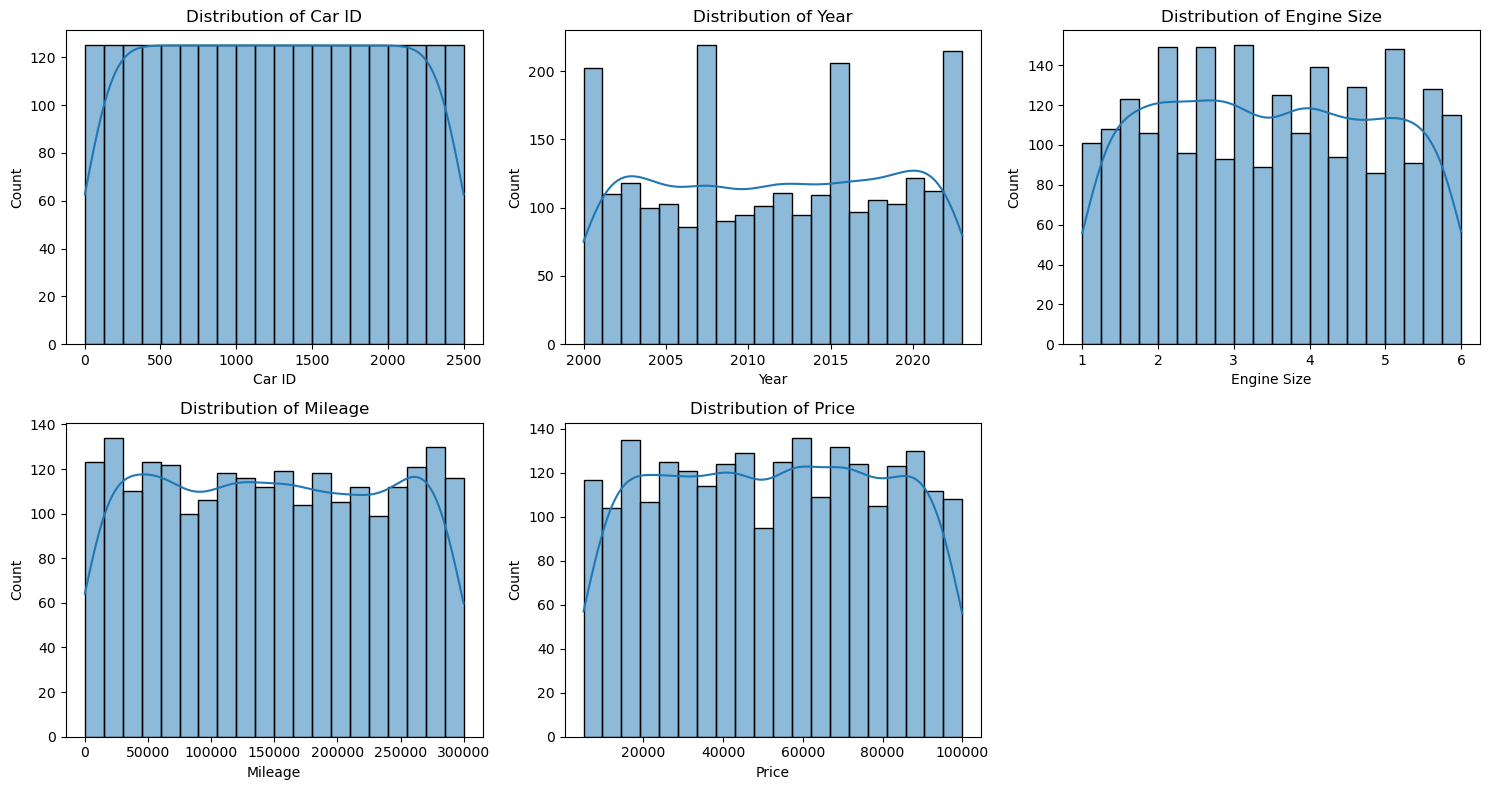

In [381]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = numeric_cols.columns
n = len(cols)

cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))

axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

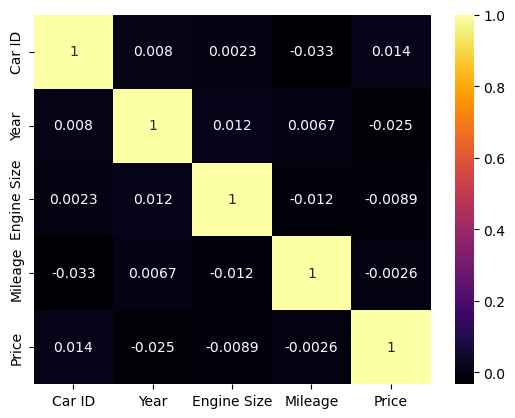

In [382]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='inferno')

# Preprocessing

In [383]:
df.isnull().sum()

Car ID            0
Brand             0
Year              0
Engine Size     175
Fuel Type       125
Transmission    150
Mileage         200
Condition       100
Price           125
Model            75
dtype: int64

In [384]:
df = df.drop(['Car ID'], axis=1)

In [385]:

df['Car Age'] = 2026 - df['Year']

df['Mileage per year'] = df['Mileage'] / (df['Car Age'] + 1)

def engine_group(x):
    if x < 1.6:
        return 'Small'
    elif x < 2.5:
        return 'Medium'
    else:
        return 'Large'

df['Engine Category'] = df['Engine Size'].apply(engine_group)


In [386]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

In [387]:
cat_imputer = SimpleImputer(strategy='most_frequent')

In [388]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


numeric_cols = ['Car Age','Mileage per year']
categorical_cols = ['Model', 'Engine Category', 'Brand' ,'Fuel Type', 'Condition']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Model

In [389]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [390]:
df = df.dropna(subset=['Price'])

X = df.drop('Price', axis=1)
y = df['Price']

In [391]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42 )

In [392]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [393]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 24263.183016794766
RMSE: 28245.465966077092
R2 Score: -0.03209796150042443
